In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

import gc

In [3]:
games = pd.read_csv('games.csv',nrows=26294)
games_details = pd.read_csv('games_details.csv')
players = pd.read_csv('players.csv')
teams = pd.read_csv('teams.csv')
ranking = pd.read_csv('ranking.csv')

games.head(10)

/var/folders/sd/hj4zy7490lv2rrwbsv294vcw0000gp/T/ipykernel_54651/2493731261.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  games_details = pd.read_csv('games_details.csv')


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,11/27/22,22200290,Final,1610612751,1610612757,2022,1610612751,111,0.526,0.778,...,27,38,1610612757,97,0.443,0.682,0.364,27,42,1
1,11/27/22,22200291,Final,1610612750,1610612744,2022,1610612750,114,0.443,0.759,...,22,31,1610612744,137,0.575,0.850,0.426,36,47,0
2,11/27/22,22200292,Final,1610612746,1610612754,2022,1610612746,114,0.447,0.750,...,33,62,1610612754,100,0.383,0.826,0.214,23,39,1
3,11/27/22,22200293,Final,1610612737,1610612748,2022,1610612737,98,0.398,0.947,...,24,42,1610612748,106,0.488,0.895,0.273,28,46,0
4,11/27/22,22200294,Final,1610612738,1610612764,2022,1610612738,130,0.550,1.000,...,25,38,1610612764,121,0.537,0.788,0.250,23,29,1
5,11/27/22,22200295,Final,1610612765,1610612739,2022,1610612765,94,0.456,0.538,...,14,36,1610612739,102,0.429,0.848,0.286,14,41,0
6,11/27/22,22200296,Final,1610612752,1610612763,2022,1610612752,123,0.506,0.833,...,30,42,1610612763,127,0.484,0.742,0.375,32,50,0
7,11/27/22,22200297,Final,1610612753,1610612755,2022,1610612753,103,0.456,0.760,...,21,26,1610612755,133,0.649,0.815,0.407,32,43,0
8,11/27/22,22200298,Final,1610612749,1610612742,2022,1610612749,124,0.558,0.733,...,28,40,1610612742,115,0.513,0.640,0.415,23,32,1
9,11/26/22,22200286,Final,1610612761,1610612742,2022,1610612761,105,0.432,0.808,...,20,48,1610612742,100,0.479,0.792,0.282,28,34,1


In [27]:
gc.collect()

5130

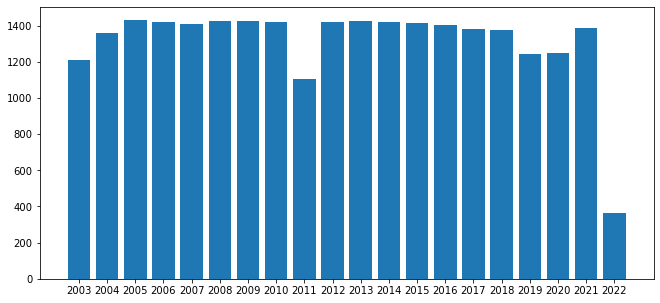

In [3]:
fig, ax = plt.subplots(figsize=(11,5))

v_c = games['SEASON'].value_counts().sort_index()
v_c.index = v_c.index.astype(str)
ax.bar(v_c.index, v_c.values)

plt.show()

In [4]:
# Creating the empty dictionary that is going to store the current elo for each team
import eloUtils
current_elo={}
x = []
y = []
games =  games.loc[::-1]
for idx,row in games.iterrows():
    # Getting the data that it is nedeed to calculate the elo 
    home=row['TEAM_ID_home']
    away=row['TEAM_ID_away']
    home_pts=row['PTS_home']
    away_pts=row['PTS_away']


    # Getting elo before match. If it is the first match played, the elo is initialized in 1500.
    if home not in current_elo.keys():
        current_elo[home]=1500
    
    if away not in current_elo.keys():
        current_elo[away]=1500
    
    #calculating and updating elo
    elo_h=current_elo[home]
    elo_aw=current_elo[away]
    elo_ln,elo_vn=eloUtils.calculate_elo(elo_h,elo_aw,home_pts,away_pts)

    current_elo[home]=elo_ln
    current_elo[away]=elo_vn

    if (home == 1610612744):
        y.append(current_elo[home])
        x.append(row['GAME_DATE_EST'])
    if (away == 1610612744):
         y.append(current_elo[away])
         x.append(row['GAME_DATE_EST'])
    
    
    #Saving results in dataframe
    games.loc[idx,'Elo_h_after']=elo_ln
    games.loc[idx,'Elo_a_after']=elo_vn 
    games.loc[idx,'Elo_h_before']=elo_h
    games.loc[idx,'Elo_a_before']=elo_aw

games =  games.loc[::-1]

In [5]:
games.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS,Elo_h_after,Elo_a_after,Elo_h_before,Elo_a_before
0,11/20/22,22200240,Final,1610612756,1610612752,2022,1610612756,116,0.426,0.722,...,0.400,0.800,0.280,20,39,1,1671.376456,1489.500710,1661.859529,1499.017637
1,11/20/22,22200241,Final,1610612764,1610612766,2022,1610612764,106,0.430,0.722,...,0.390,0.696,0.250,19,51,1,1443.755691,1380.151996,1438.384275,1385.523412
2,11/20/22,22200242,Final,1610612758,1610612765,2022,1610612758,137,0.553,0.886,...,0.528,0.870,0.517,20,35,1,1496.594415,1255.398495,1492.838585,1259.154325
3,11/20/22,22200243,Final,1610612751,1610612763,2022,1610612751,127,0.602,0.733,...,0.434,0.548,0.324,28,44,1,1516.197052,1607.165623,1500.640241,1622.722434
4,11/20/22,22200244,Final,1610612739,1610612748,2022,1610612739,113,0.530,0.750,...,0.388,0.864,0.194,17,30,1,1535.965949,1607.858095,1509.486490,1634.337554


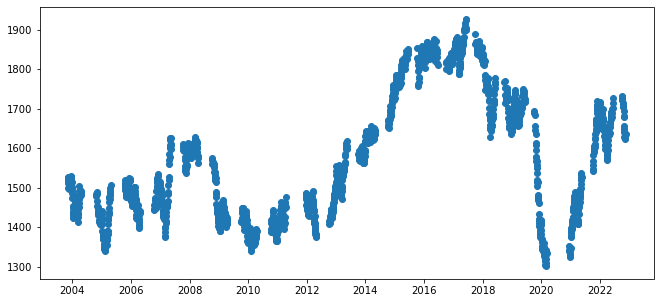

In [6]:
x = [pd.to_datetime(d) for d in x]
fig, ax = plt.subplots(figsize=(11,5))
ax.scatter(x,y)
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



cols = ['Elo_h_before','Elo_a_before']

features = games[cols].values
label = games['HOME_TEAM_WINS'].values

x_train, x_test, y_train, y_test = train_test_split(features, label, test_size = 0.2)

/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

rf = RandomForestClassifier(n_estimators = 1800,
 min_samples_split = 2,
 min_samples_leaf = 4,
 max_features = "sqrt",
 max_depth = 20,
 bootstrap = True)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print(metrics.accuracy_score(y_test, y_pred_rf))

from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(rf.get_params())



0.6486023958927553
Parameters currently in use:

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 20,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 1800,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}


In [7]:
# Query nba.live.endpoints.scoreboard and  list games in localTimeZone
from datetime import datetime, timezone
from dateutil import parser
from nba_api.live.nba.endpoints import scoreboard

f = "{gameId}: {homeTeam}  vs. {awayTeam} @ {gameTimeLTZ}" 

board = scoreboard.ScoreBoard()
print("ScoreBoardDate: " + board.score_board_date)
games = board.games.get_dict()
for game in games:
    gameTimeLTZ = parser.parse(game["gameTimeUTC"]).replace(tzinfo=timezone.utc).astimezone(tz=None)
    print(f.format(gameId=game['gameId'], awayTeam=game['awayTeam']['teamName'], homeTeam=game['homeTeam']['teamName'], gameTimeLTZ=gameTimeLTZ))
    print("Home: " + str(current_elo[game['homeTeam']['teamId']]) + " Away: " + str(current_elo[game['awayTeam']['teamId']]))
    print(rf.predict([[current_elo[game['homeTeam']['teamId']],current_elo[game['awayTeam']['teamId']]]]))

ScoreBoardDate: 2022-11-29
0022200309: Pistons  vs. Knicks @ 2022-11-29 19:00:00-05:00
Home: 1275.0700861639607 Away: 1484.0458682179099
[0]
0022200310: Mavericks  vs. Warriors @ 2022-11-29 19:30:00-05:00
Home: 1602.0771804190347 Away: 1634.9125249495746
[1]
0022200311: Trail Blazers  vs. Clippers @ 2022-11-29 22:00:00-05:00
Home: 1319.3281230423315 Away: 1496.847152535123
[0]


In [35]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 0, stop = 2000, num = 11)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(0, 100, num = 6)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
pprint(random_grid)

# Use the random grid to search for best hyperparameters
# First create the base model to tune
rfc = RandomForestClassifier(random_state=42)
# Random search of parameters, using 2-fold cross validation, 
# search across 100 different combinations, and use all available cores
rfc_random = RandomizedSearchCV(estimator = rfc, param_distributions = random_grid, n_iter = 100, cv = 2, verbose=2, n_jobs = -1)
# Fit the random search model
rfc_random.fit(x_train, y_train)
y_pred_rfr_random = rfc_random.predict(x_test)
print(metrics.accuracy_score(y_test, y_pred_rfr_random))

{'bootstrap': [True, False],
 'max_depth': [0, 20, 40, 60, 80, 100, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}
Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END bootstrap=False, max_depth=None, max_features=auto, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   7.7s
[CV] END bootstrap=False, max_depth=None, max_features=auto, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   7.7s
[CV] END bootstrap=True, max_depth=20, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=800; total time=  26.4s
[CV] END bootstrap=True, max_depth=20, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=800; total time=  26.6s
[CV] END bootstrap=False, max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=  

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
42 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
14 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py", line 392, in fit
    self._validate_estimator()
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_base.py", line 138, in _validate_estimator
    raise ValueError(
ValueError: n_estimators must be greater than 

0.6423274386765545


In [36]:
rfc_random.best_params_

{'n_estimators': 1800,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 20,
 'bootstrap': True}